In [46]:
import zipfile
import os
import pandas as pd

dataset_folder = 'dataset'
output_folder = 'extracted_dataset'

os.makedirs(output_folder, exist_ok=True)

for zip_file in os.listdir(dataset_folder):
    if zip_file.endswith('.zip'):
        label_name = zip_file.replace('.zip', '')
        zip_path = os.path.join(dataset_folder, zip_file)
        extract_path = os.path.join(output_folder, label_name)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

data = []
CATEGORIES = [name.lower() for name in ['Acne', 'Ringworm', 'Vitiligo']]


for label in CATEGORIES:
    folder_path = os.path.join(output_folder, label)
    if not os.path.isdir(folder_path):
        continue
    for root, _, files in os.walk(folder_path):
        for img_name in files:
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, img_name)
                data.append((img_path, label))



df = pd.DataFrame(data, columns=['file_path', 'label'])

In [1]:
import os

dataset_path = 'extracted_dataset/'

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        total_images = 0
        for root, dirs, files in os.walk(class_path):
            image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            total_images += len(image_files)
        print(f"{class_name}: {total_images} images")


acne: 1832 images
ringworm: 204 images
Vitiligo: 2017 images


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

dataset_path = 'extracted_dataset'  
image_size = 224
batch_size = 32
epochs = 10

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


num_classes = train_data.num_classes
print("Number of classes:", num_classes)
print("Class indices:", train_data.class_indices)


base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))
base_model.trainable = False 


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x) 

model = Model(inputs=base_model.input, outputs=predictions)


model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


model.fit(train_data, validation_data=val_data, epochs=epochs)


model.save("skin_disease_classifier.h5")


Found 3244 images belonging to 3 classes.
Found 809 images belonging to 3 classes.
Number of classes: 3
Class indices: {'Vitiligo': 0, 'acne': 1, 'ringworm': 2}


C:\Users\sj945\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.4480 - loss: 1.2085 - val_accuracy: 0.6984 - val_loss: 0.7338
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 65s 635ms/step - accuracy: 0.7022 - loss: 0.7178 - val_accuracy: 0.7651 - val_loss: 0.6176
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 64s 629ms/step - accuracy: 0.7738 - loss: 0.6018 - val_accuracy: 0.8072 - val_loss: 0.5247
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 64s 628ms/step - accuracy: 0.8097 - loss: 0.4922 - val_accuracy: 0.8208 - val_loss: 0.4776
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 65s 640ms/step - accuracy: 0.8316 - loss: 0.4471 - val_accuracy: 0.8418 - val_loss: 0.4304
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 65s 642ms/step - accuracy: 0.8551 - loss: 0.4096 - val_accuracy: 0.8566 - val_loss: 0.4143
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 65s 641ms/step - accuracy: 0.8751 - loss: 0.3572 - val_accuracy: 0.8653 - val_loss: 0.3852
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 66s 643ms/step - accuracy: 0.8745 - loss: 0.3

In [80]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight


dataset_path = 'extracted_dataset/'  
image_size = 224
batch_size = 32
epochs = 50


datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights_array))

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))
base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


model.fit(train_data, validation_data=val_data, epochs=epochs, class_weight=class_weights, callbacks=[early_stopping])


model.save("skin_disease_classifier.h5")


val_loss, val_accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {val_accuracy}")


Found 3244 images belonging to 3 classes.
Found 809 images belonging to 3 classes.


C:\Users\sj945\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 686ms/step - accuracy: 0.5562 - loss: 1.1144 - val_accuracy: 0.7553 - val_loss: 0.6259
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 68s 671ms/step - accuracy: 0.7610 - loss: 0.6683 - val_accuracy: 0.7244 - val_loss: 0.6779
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 68s 664ms/step - accuracy: 0.8124 - loss: 0.4945 - val_accuracy: 0.8072 - val_loss: 0.4888
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 69s 677ms/step - accuracy: 0.8625 - loss: 0.3928 - val_accuracy: 0.7837 - val_loss: 0.5187
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 68s 669ms/step - accuracy: 0.8441 - loss: 0.4179 - val_accuracy: 0.8529 - val_loss: 0.3880
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 69s 679ms/step - accuracy: 0.8830 - loss: 0.3427 - val_accuracy: 0.8220 - val_loss: 0.4551
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 69s 674ms/step - accuracy: 0.8618 - loss: 0.3742 - val_accuracy: 0.8517 - val_loss: 0.4031
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 69s 679ms/step - accuracy: 0.8772 - loss: 0

26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 619ms/step - accuracy: 0.9188 - loss: 0.2066
Validation Accuracy: 0.9085290431976318


In [82]:
print(train_data.class_indices)

{'Vitiligo': 0, 'acne': 1, 'ringworm': 2}


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os

model = tf.keras.models.load_model('skin_disease_classifier.h5', compile=False)


class_labels = [ 'Vitiligo', 'acne', 'ringworm']  

img_path = 'test_image10.jpg'


img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0  


predictions = model.predict(img_array)
predicted_class = class_labels[np.argmax(predictions)]


print("Predicted Class:", predicted_class)
print("Confidence Scores:", predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Class: ringworm
Confidence Scores: [[0.07720568 0.1652074  0.75758696]]


In [10]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


model = load_model("skin_disease_classifier.h5")


class_labels = ['Vitiligo', 'acne', 'ringworm']  


image_path = 'test_image_11.jpg'  
img = cv2.imread(image_path)
img_resized = cv2.resize(img, (224, 224))   
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)  
img_array = np.expand_dims(img_rgb, axis=0)
img_array = preprocess_input(img_array)


predictions = model.predict(img_array)
predicted_class = class_labels[np.argmax(predictions)]
confidence_scores = predictions[0]


print(f"Predicted Class: {predicted_class}")
print("Confidence Scores:", confidence_scores)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
Predicted Class: Vitiligo
Confidence Scores: [0.5756696  0.41813532 0.00619515]


In [24]:
import os
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

dataset_path = 'extracted_dataset'
image_size = 224
batch_size = 32
epochs = 20

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Class indices:", train_data.class_indices)

labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    3 
    restore_best_weights=True,
    verbose=1
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[early_stop]
)

model.save("efficientnet_skin_disease_classifier.h5")


Found 3244 images belonging to 3 classes.
Found 810 images belonging to 3 classes.
Class indices: {'Vitiligo': 0, 'acne': 1, 'ringworm': 2}
Class Weights: {0: 0.6699710863279636, 1: 0.7376080036380173, 2: 6.59349593495935}


C:\Users\sj945\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - accuracy: 0.4484 - loss: 1.1220 - val_accuracy: 0.4296 - val_loss: 1.0647
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.6117 - loss: 0.8683 - val_accuracy: 0.5654 - val_loss: 0.9326
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.7038 - loss: 0.8078 - val_accuracy: 0.6395 - val_loss: 0.8469
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.7319 - loss: 0.7338 - val_accuracy: 0.6494 - val_loss: 0.8012
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.7705 - loss: 0.7058 - val_accuracy: 0.6852 - val_loss: 0.7417
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.8135 - loss: 0.5827 - val_accuracy: 0.6790 - val_loss: 0.7129
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accuracy: 0.8276 - loss: 0.5257 - val_accuracy: 0.7086 - val_loss: 0.6684
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 286s 3s/step - accuracy: 0.8431 - loss: 0.5239 - val_accu

In [20]:
print(train_data.class_indices)


{'Vitiligo': 0, 'acne': 1, 'ringworm': 2}


In [38]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess


model = load_model("efficientnet_skin_disease_classifier.h5")


class_labels = ['Vitiligo', 'acne', 'ringworm']  


image_path = 'test_image10.jpg' 
img = cv2.imread(image_path)
img_resized = cv2.resize(img, (224, 224))
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
img_array = np.expand_dims(img_rgb, axis=0)
img_array = efficientnet_preprocess(img_array)  


predictions = model.predict(img_array)
predicted_class = class_labels[np.argmax(predictions)]
confidence_scores = predictions[0]

print(f"Predicted Class: {predicted_class}")
print("Confidence Scores:", confidence_scores)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Class: ringworm
Confidence Scores: [0.28396538 0.02194802 0.69408655]


In [9]:
pip install seaborn --upgrade

Note: you may need to restart the kernel to use updated packages.


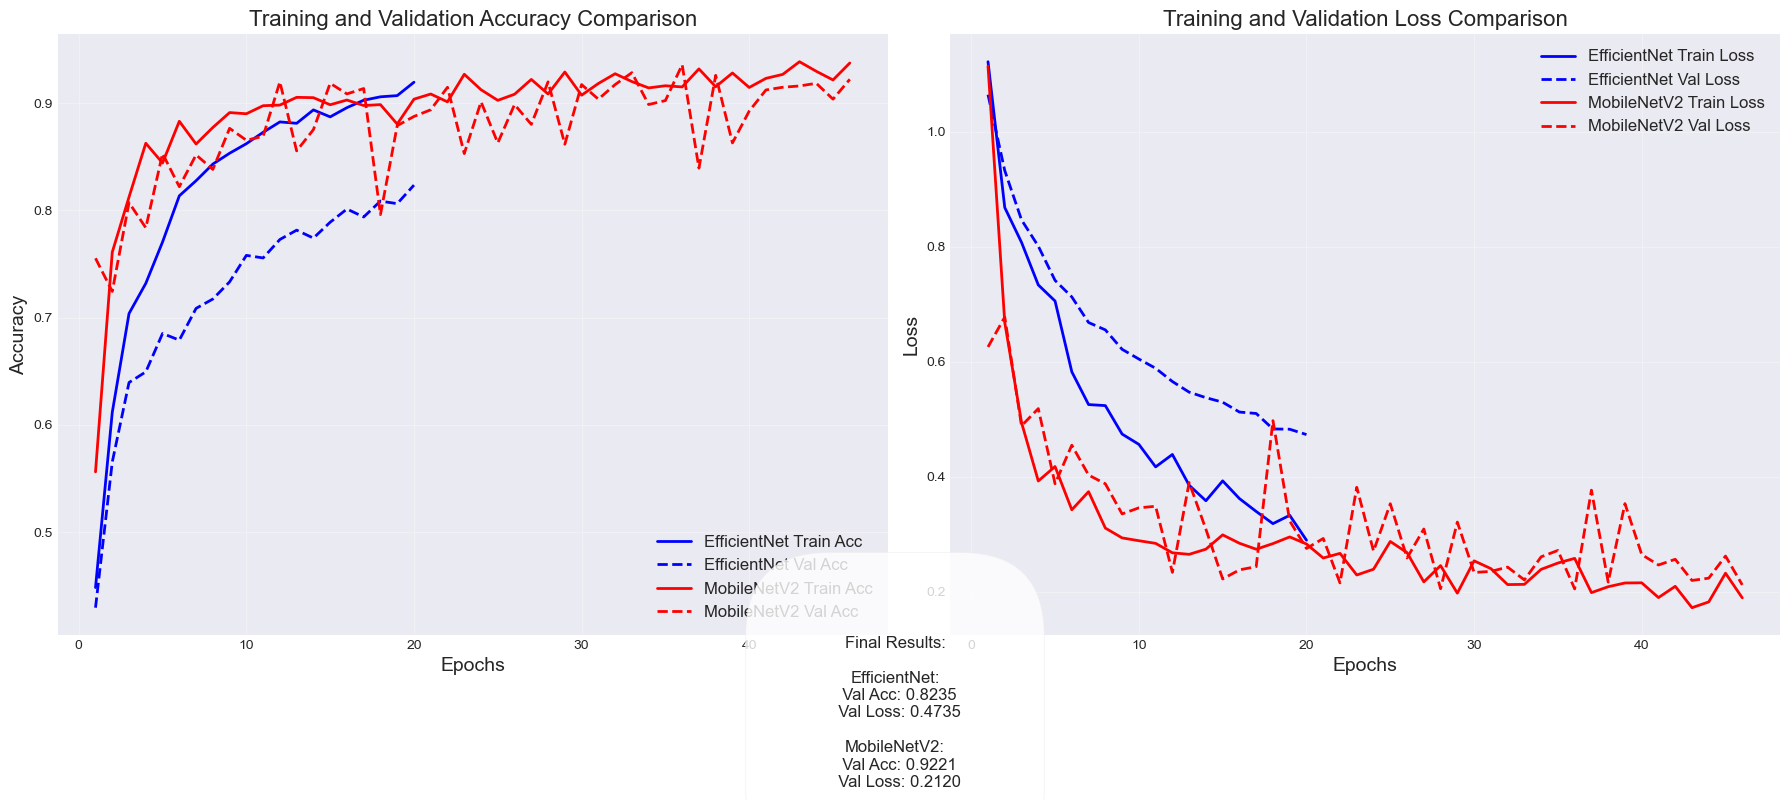


Model Performance Comparison:
--------------------------------------------------
EfficientNet (20 epochs):
  - Final validation accuracy: 0.8235
  - Final validation loss: 0.4735
  - Training time: Longer (as shown in logs)

MobileNetV2 (46 epochs):
  - Final validation accuracy: 0.9221
  - Final validation loss: 0.2120
  - Training time: Faster per epoch
--------------------------------------------------
Best validation accuracy: MobileNetV2 (0.9221)
Best validation loss: MobileNetV2 (0.2120)


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Model 1 (EfficientNet) data
model1_train_acc = [0.4484, 0.6117, 0.7038, 0.7319, 0.7705, 0.8135, 0.8276, 0.8431, 0.8532, 0.8621, 
                    0.8727, 0.8824, 0.8811, 0.8936, 0.8871, 0.8957, 0.9026, 0.9058, 0.9069, 0.9194]
model1_val_acc = [0.4296, 0.5654, 0.6395, 0.6494, 0.6852, 0.6790, 0.7086, 0.7173, 0.7333, 0.7580, 
                  0.7556, 0.7728, 0.7815, 0.7741, 0.7889, 0.8012, 0.7938, 0.8086, 0.8062, 0.8235]
model1_train_loss = [1.1220, 0.8683, 0.8078, 0.7338, 0.7058, 0.5827, 0.5257, 0.5239, 0.4744, 0.4565, 
                     0.4173, 0.4389, 0.3854, 0.3584, 0.3930, 0.3622, 0.3398, 0.3186, 0.3331, 0.2898]
model1_val_loss = [1.0647, 0.9326, 0.8469, 0.8012, 0.7417, 0.7129, 0.6684, 0.6556, 0.6218, 0.6049, 
                   0.5888, 0.5658, 0.5473, 0.5377, 0.5298, 0.5127, 0.5102, 0.4833, 0.4828, 0.4735]

# Model 2 (MobileNetV2) data 
model2_train_acc = [
    0.5562, 0.7610, 0.8124, 0.8625, 0.8441, 0.8830, 0.8618, 0.8772, 0.8911, 0.8900,
    0.8975, 0.8981, 0.9053, 0.9050, 0.8984, 0.9028, 0.8977, 0.8985, 0.8804, 0.9036,
    0.9084, 0.9011, 0.9268, 0.9124, 0.9025, 0.9082, 0.9220, 0.9084, 0.9289, 0.9073,
    0.9182, 0.9273, 0.9200, 0.9141, 0.9161, 0.9150, 0.9318, 0.9152, 0.9280, 0.9145,
    0.9230, 0.9267, 0.9385, 0.9296, 0.9215, 0.9373
]

model2_val_acc = [
    0.7553, 0.7244, 0.8072, 0.7837, 0.8529, 0.8220, 0.8517, 0.8381, 0.8764, 0.8653,
    0.8690, 0.9197, 0.8554, 0.8752, 0.9184, 0.9085, 0.9135, 0.7960, 0.8789, 0.8875,
    0.8937, 0.9147, 0.8529, 0.9011, 0.8628, 0.8986, 0.8801, 0.9197, 0.8616, 0.9172,
    0.9036, 0.9172, 0.9283, 0.8986, 0.9023, 0.9357, 0.8393, 0.9258, 0.8628, 0.8925,
    0.9122, 0.9147, 0.9159, 0.9184, 0.9036, 0.9221
]

model2_train_loss = [
    1.1144, 0.6683, 0.4945, 0.3928, 0.4179, 0.3427, 0.3742, 0.3109, 0.2938, 0.2889,
    0.2843, 0.2679, 0.2652, 0.2742, 0.2991, 0.2845, 0.2741, 0.2839, 0.2955, 0.2832,
    0.2588, 0.2669, 0.2293, 0.2393, 0.2876, 0.2682, 0.2173, 0.2456, 0.1977, 0.2539,
    0.2404, 0.2126, 0.2130, 0.2391, 0.2501, 0.2582, 0.1986, 0.2089, 0.2154, 0.2157,
    0.1900, 0.2096, 0.1724, 0.1825, 0.2324, 0.1895
]

model2_val_loss = [
    0.6259, 0.6779, 0.4888, 0.5187, 0.3880, 0.4551, 0.4031, 0.3879, 0.3355, 0.3461,
    0.3488, 0.2339, 0.3901, 0.3088, 0.2224, 0.2382, 0.2438, 0.4977, 0.3233, 0.2754,
    0.2928, 0.2155, 0.3818, 0.2709, 0.3532, 0.2589, 0.3093, 0.2054, 0.3213, 0.2337,
    0.2355, 0.2430, 0.2207, 0.2609, 0.2720, 0.2051, 0.3768, 0.2169, 0.3534, 0.2648,
    0.2467, 0.2566, 0.2198, 0.2238, 0.2622, 0.2120
]

epochs1 = range(1, len(model1_train_acc) + 1)
epochs2 = range(1, len(model2_train_acc) + 1)

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs1, model1_train_acc, 'b-', linewidth=2, label='EfficientNet Train Acc')
plt.plot(epochs1, model1_val_acc, 'b--', linewidth=2, label='EfficientNet Val Acc')
plt.plot(epochs2, model2_train_acc, 'r-', linewidth=2, label='MobileNetV2 Train Acc')
plt.plot(epochs2, model2_val_acc, 'r--', linewidth=2, label='MobileNetV2 Val Acc')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Training and Validation Accuracy Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs1, model1_train_loss, 'b-', linewidth=2, label='EfficientNet Train Loss')
plt.plot(epochs1, model1_val_loss, 'b--', linewidth=2, label='EfficientNet Val Loss')
plt.plot(epochs2, model2_train_loss, 'r-', linewidth=2, label='MobileNetV2 Train Loss')
plt.plot(epochs2, model2_val_loss, 'r--', linewidth=2, label='MobileNetV2 Val Loss')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Training and Validation Loss Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()

final_acc1 = model1_val_acc[-1]
final_acc2 = model2_val_acc[-1]
final_loss1 = model1_val_loss[-1]
final_loss2 = model2_val_loss[-1]

summary_text = f"Final Results:\n\nEfficientNet:\n  Val Acc: {final_acc1:.4f}\n  Val Loss: {final_loss1:.4f}\n\nMobileNetV2:\n  Val Acc: {final_acc2:.4f}\n  Val Loss: {final_loss2:.4f}"

plt.figtext(0.5, 0.01, summary_text, ha="center", fontsize=12, 
            bbox={"facecolor":"white", "alpha":0.8, "pad":5, "boxstyle":"round"})

plt.subplots_adjust(bottom=0.2)
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nModel Performance Comparison:")
print("-" * 50)
print(f"EfficientNet (20 epochs):")
print(f"  - Final validation accuracy: {final_acc1:.4f}")
print(f"  - Final validation loss: {final_loss1:.4f}")
print(f"  - Training time: Longer (as shown in logs)")
print("\nMobileNetV2 (46 epochs):")
print(f"  - Final validation accuracy: {final_acc2:.4f}")
print(f"  - Final validation loss: {final_loss2:.4f}")
print(f"  - Training time: Faster per epoch")
print("-" * 50)
print(f"Best validation accuracy: {'EfficientNet' if final_acc1 > final_acc2 else 'MobileNetV2'} ({max(final_acc1, final_acc2):.4f})")
print(f"Best validation loss: {'EfficientNet' if final_loss1 < final_loss2 else 'MobileNetV2'} ({min(final_loss1, final_loss2):.4f})")
